In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Ecommerce.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.columns)

Dataset Shape: (25000, 29)
   customer_id  session_id  visit_date  device_type  user_type  \
0         1803           0  28-11-2024            2          1   
1         7964           1  25-09-2024            2          0   
2         6890           2  31-05-2024            1          1   
3         4949           3  30-01-2024            1          0   
4         4896           4  25-02-2024            1          1   

   marketing_channel  product_id  product_category  unit_price  quantity  ...  \
0                  2         894                 6      651.57         1  ...   
1                  4         844                 2      945.27         4  ...   
2                  0         865                 0      400.44         4  ...   
3                  2         851                 3     1268.54         2  ...   
4                  5         794                 3      880.81         3  ...   

   review_text  review_helpful_votes  payment_method  visit_day  visit_month  \
0        

In [3]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [4]:
df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

After removing duplicates: (25000, 29)


In [5]:
popular_products = (
    df.groupby("product_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

print(popular_products)

product_id
499    45
94     44
715    44
98     43
858    43
686    43
338    43
14     42
215    42
177    42
dtype: int64


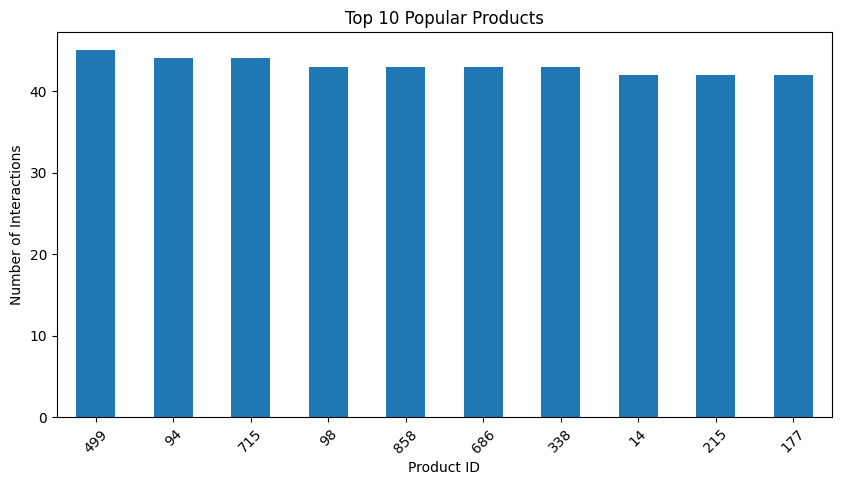

In [6]:
plt.figure(figsize=(10,5))

popular_products.plot(kind="bar")

plt.title("Top 10 Popular Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=45)
plt.show()

In [7]:
purchase_count = df["purchased"].value_counts()

print(purchase_count)

purchased
0    19384
1     5616
Name: count, dtype: int64


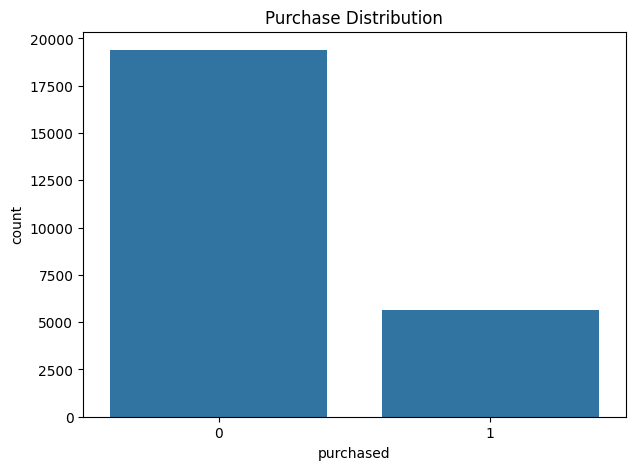

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="purchased")

plt.title("Purchase Distribution")
plt.show()

In [9]:
user_product_matrix = df.pivot_table(
    index="customer_id",
    columns="product_id",
    values="rating",
    aggfunc="mean"
)

print(user_product_matrix.head())

user_product_matrix = user_product_matrix.fillna(0)

print(user_product_matrix.shape)

product_id   0    1    2    3    4    5    6    7    8    9    ...  889  890  \
customer_id                                                    ...             
1000         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN   
1001         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN   
1002         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN   
1003         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN   
1004         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN   

product_id   891  892  893  894  895  896  897  898  
customer_id                                          
1000         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1001         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1002         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1003         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1004         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 899 columns]
(8442, 899)


In [10]:
product_similarity = cosine_similarity(user_product_matrix.T)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=user_product_matrix.columns,
    columns=user_product_matrix.columns
)

print(product_similarity_df.head())

product_id       0    1         2    3    4         5         6    7    8    \
product_id                                                                    
0           1.000000  0.0  0.035353  0.0  0.0  0.000000  0.031874  0.0  0.0   
1           0.000000  1.0  0.000000  0.0  0.0  0.000000  0.000000  0.0  0.0   
2           0.035353  0.0  1.000000  0.0  0.0  0.000000  0.000000  0.0  0.0   
3           0.000000  0.0  0.000000  1.0  0.0  0.000000  0.000000  0.0  0.0   
4           0.000000  0.0  0.000000  0.0  1.0  0.037253  0.000000  0.0  0.0   

product_id       9    ...  889  890  891       892  893       894  895  896  \
product_id            ...                                                     
0           0.000000  ...  0.0  0.0  0.0  0.000000  0.0  0.000000  0.0  0.0   
1           0.000000  ...  0.0  0.0  0.0  0.000000  0.0  0.042426  0.0  0.0   
2           0.000000  ...  0.0  0.0  0.0  0.000000  0.0  0.000000  0.0  0.0   
3           0.046524  ...  0.0  0.0  0.0  0.035567 

In [11]:
def recommend_products(product_id, n=5):

    if product_id not in product_similarity_df.index:
        return "Product not found"

    similar_products = product_similarity_df[product_id].sort_values(
        ascending=False
    )

    similar_products = similar_products.drop(product_id)

    return similar_products.head(n)

In [12]:
product_id = user_product_matrix.columns[0]

print("Selected Product:", product_id)

Selected Product: 0


In [13]:
recommendations = recommend_products(product_id, 5)

print("Recommended Products:")
print(recommendations)

Recommended Products:
product_id
405    0.071964
488    0.069595
857    0.063597
96     0.056366
83     0.054300
Name: 0, dtype: float64


In [14]:
def recommend_for_user(customer_id, n=5):

    if customer_id not in user_product_matrix.index:
        return "Customer not found"

    user_ratings = user_product_matrix.loc[customer_id]

    purchased_products = user_ratings[
        user_ratings > 0
    ].index

    scores = {}

    for product in purchased_products:

        similar_products = product_similarity_df[product]

        for similar_product, similarity_score in similar_products.items():

            if similar_product not in purchased_products:

                scores[similar_product] = (
                    scores.get(similar_product, 0)
                    + similarity_score
                )

    recommendations = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:n]

In [15]:
customer_id = user_product_matrix.index[0]

recommendations = recommend_for_user(
    customer_id,
    5
)

print("Customer:", customer_id)
print("Recommendations:")

for product, score in recommendations:
    print(product, round(score, 3))

Customer: 1000
Recommendations:
133 0.088
119 0.086
435 0.085
486 0.083
666 0.08


In [16]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Training data:", train.shape)
print("Testing data:", test.shape)

Training data: (20000, 29)
Testing data: (5000, 29)
